For this part of the project, I am first exploring the files in my `data/taltech-u06-weather` directory. These are from a project titled "Collected data from Weather station of Tallinn University of Technology (U06) January-August 2025 [Data set]", which was publishe din 2025 and done by Volkova, A. and Wani, M. B. It is accessible through: https://data.taltech.ee/records/zhev3-e5r64 

In [65]:
# Just in case they are needed...

%pip install openpyxl
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install seaborn
%pip install scipy
%pip install scikit-learn

You should consider upgrading via the '/usr/local/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
You should consider upgrading via the '/usr/local/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
You should consider upgrading via the '/usr/local/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
You should consider upgrading via the '/usr/local/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
You should consider upgrading via the '/usr/local/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
You should consider upgrading via the '/usr/local/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages

In [66]:
# Imports

from pathlib import Path
import pandas as pd
from openpyxl import load_workbook
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

import os

In [67]:
WEATHER_DATA_DIR = Path("data/taltech-u06-weather")

files = list(WEATHER_DATA_DIR.glob("*.xlsx"))

print(f"Found {len(files)} files in {WEATHER_DATA_DIR}\n")
for i, file in enumerate(files):
    print(f"{i+1}. {file.name}")


Found 8 files in data/taltech-u06-weather

1. Direct Normal Irradiance Jan-August 2025.xlsx
2. Wind Speed Jan-Aug 2025.xlsx
3. Weather Station Maintenance.xlsx
4. Temperature_TalTech_ Jan -August Jan-August 2025.xlsx
5. Diffuse Horizontal Irradiance Jan-August 2025.xlsx
6. Global Horizontal Irradiance Jan-August 2025.xlsx
7. Ambient Pressure Jan-August 2025.xlsx
8. Relative Humidity Jan-Aug 2025.xlsx


In [68]:
CAMPUS_DATA_DIR = Path("data/campus-data")

directories = list(CAMPUS_DATA_DIR.glob("*"))

# "- 1" because there is a _README.md file in the directory
print(f"Found {len(directories) - 1} directories in {CAMPUS_DATA_DIR}\n")

Found 20 directories in data/campus-data



In [69]:
CAMPUS_DATA_OVERVIEW_FILE = CAMPUS_DATA_DIR / "andmed ulevaade.xlsx"
CAMPUS_BUILDING_CODES_FILE = CAMPUS_DATA_DIR / "hooned koodid.xlsx"
WEATHER_DATA_FILE = "data/keskkonnaportaal/tallinn-harku_f_kliima_tund.csv"

# Read the overview file
overview_df = pd.read_excel(CAMPUS_DATA_OVERVIEW_FILE)

# Read the building codes file
building_codes_df = pd.read_excel(CAMPUS_BUILDING_CODES_FILE)

# Extract hyperlinks from Excel file
wb = load_workbook(CAMPUS_BUILDING_CODES_FILE, data_only=False)
ws = wb.active

# Find "EHR register" column (column B)
ehr_column_letter = "B"

# Extract hyperlinks
hyperlinks = []
for row_idx in range(2, ws.max_row + 1):
    cell = ws[f"{ehr_column_letter}{row_idx}"]
    url = cell.hyperlink.target if cell.hyperlink else None
    hyperlinks.append(url)

building_codes_df["EHR register URL"] = hyperlinks[:len(building_codes_df)]


In [70]:
# Shape
print(f"Overview file ({CAMPUS_DATA_OVERVIEW_FILE}) has {overview_df.shape[0]} rows and {overview_df.shape[1]} columns")

# Overview file
overview_df.head(5)

Overview file (data/campus-data/andmed ulevaade.xlsx) has 163 rows and 20 columns


,Hoone,Meedium,Mõõtepunkti ID,ID convert,System,building_abv,level,point_id,point_name,type,algus,lõpp,unit,mõõdetud,2022,2023,2024,kommentaarid,Unnamed: 18,Unnamed: 19
0,GEO,Soojus,GEO.BHB01,GEO.BHB01,Peaarvesti (GEO korpus),GEO,main,17256,S - GEO.BHB01 - Nait - 85445487,peaarvesti,2024-05-22,2024-12-31,MWh,näit,NaN,NaN,GEO_BHB01_näit_2024.csv,NaN,NaN,andmed puudu
1,GEO,Soojus,GEO.BHB01,GEO.BHB01,Peaarvesti (GEO korpus),GEO,main,17256,S - GEO.BHB01 - Labivool (hetkel - 85445487,peaarvesti,2024-05-22,2024-12-31,m3/h,läbivool,NaN,NaN,GEO_BHB01_Läbivool_2024.csv,NaN,NaN,andmed täielikult olemas
2,GEO,Soojus,GEO.BHB01,GEO.BHB01,Peaarvesti (GEO korpus),GEO,main,17256,S - GEO.BHB01 - Vooluhulk - 85445487,peaarvesti,2024-05-22,2024-12-31,m3,vooluhulk,NaN,NaN,GEO_BHB01_vooluhulk_2024.csv,NaN,NaN,"andmed olemas, mõõdetud osaliselt"
3,GEO,Soojus,GEO.BHB01,GEO.BHB01,Peaarvesti (GEO korpus),GEO,main,17256,S - GEO.BHB01 - Pealevoolu temp - 85445487,peaarvesti,2024-05-22,2024-12-31,℃,pealevoolu temperatuur,NaN,NaN,GEO_BHB01_pealevoolu temp_2024.csv,NaN,NaN,NaN
4,GEO,Soojus,GEO.BHB01,GEO.BHB01,Peaarvesti (GEO korpus),GEO,main,17256,S - GEO.BHB01 - Tagasivoolu temp - 85445487,peaarvesti,2024-05-22,2024-12-31,℃,tagasivoolu temperatuur,NaN,NaN,GEO_BHB01_tagasivoolu temp_2024.csv,NaN,NaN,NaN


In [71]:
# Shape
print(f"Building codes file ({CAMPUS_BUILDING_CODES_FILE}) has {building_codes_df.shape[0]} rows and {building_codes_df.shape[1]} columns")

# Building codes file
building_codes_df.head(5)

Building codes file (data/campus-data/hooned koodid.xlsx) has 16 rows and 6 columns


,kood,EHR register,Hoone,Unnamed: 3,Unnamed: 4,EHR register URL
0,U01,link,õppehoone nr 1,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",Ehitajate tee 5/1,https://livekluster.ehr.ee/ui/ehr/v1/building/...
1,U02 (+U02B),link,TTÜ õppehoone nr 2,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",Ehitajate tee 5/2,https://livekluster.ehr.ee/ui/ehr/v1/building/...
2,U03 (+U03B),link,õppehoone nr 3,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",Ehitajate tee 5/3,https://livekluster.ehr.ee/ui/ehr/v1/building/...
3,U04,link,õppehoone nr 4,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",Ehitajate tee 5/4,https://livekluster.ehr.ee/ui/ehr/v1/building/...
4,U04B,link,õppehoone n 4B,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",Ehitajate tee 5/8,https://livekluster.ehr.ee/ui/ehr/v1/building/...


In [72]:
# Let's look at only one building - U06
print(f"There are {overview_df[overview_df['Hoone'] == 'U06'].shape[0]} rows in the overview file for building U06")

overview_df[overview_df["Hoone"] == "U06"]

There are 18 rows in the overview file for building U06


,Hoone,Meedium,Mõõtepunkti ID,ID convert,System,building_abv,level,point_id,point_name,type,algus,lõpp,unit,mõõdetud,2022,2023,2024,kommentaarid,Unnamed: 18,Unnamed: 19
130,U06,Soojus,<U06>=BHB01,U06.BHB01,Peaarvesti (U06 korpus),U06,main,4750,S - U06.BHB01 - Nait - 65178746,peaarvesti,2022-01-01,2024-01-15,MWh,näit,U06_BHB01_näit_2022.csv,U06_BHB01_näit_2023.csv,U06_BHB01_näit_2024.csv,NaN,NaN,NaN
131,U06,Soojus,<U06>=BHB01,U06.BHB01,Peaarvesti (U06 korpus),U06,main,4750,S - U06.BHB01 - Pealevoolu temp - 65178746,peaarvesti,2022-03-30,2024-01-15,℃,pealevoolu temperatuur,U06_BHB01_pealevoolu temp_2022.csv,U06_BHB01_pealevoolu temp_2023.csv,U06_BHB01_pealevoolu temp_2024.csv,NaN,NaN,NaN
132,U06,Soojus,<U06>=BHB01,U06.BHB01,Peaarvesti (U06 korpus),U06,main,4750,S - U06.BHB01 - Tagasivoolu temp - 65178746,peaarvesti,2022-03-30,2024-01-15,℃,tagasivoolu temperatuur,U06_BHB01_tagasivoolu temp_2022.csv,U06_BHB01_tagasivoolu temp_2023.csv,U06_BHB01_tagasivoolu temp_2024.csv,NaN,NaN,NaN
133,U06,Soojus,<U06>=BHB02,U06.BHB02,U06 - jääksoojus,U06,sub,5596,S - U06.BHB02 - Nait - 3040488,jääksoojus,2022-02-14,2024-12-31,MWh,näit,U06_BHB02_näit_2022.csv,U06_BHB02_näit_2023.csv,U06_BHB02_näit_2024.csv,NaN,NaN,NaN
134,U06,Soojus,<U06>=BHB02,U06.BHB02,U06 - jääksoojus,U06,sub,5596,S - U06.BHB02 - Pealevoolu temp - 3040488,jääksoojus,2022-03-30,2024-12-31,℃,pealevoolu temperatuur,U06_BHB02_pealevoolu temp_2022.csv,U06_BHB02_pealevoolu temp_2023.csv,U06_BHB02_pealevoolu temp_2024.csv,NaN,NaN,NaN
135,U06,Soojus,<U06>=BHB02,U06.BHB02,U06 - jääksoojus,U06,sub,5596,S - U06.BHB02 - Tagasivoolu temp - 3040488,jääksoojus,2022-03-30,2024-12-31,℃,tagasivoolu temperatuur,U06_BHB02_tagasivoolu temp_2022.csv,U06_BHB02_tagasivoolu temp_2023.csv,U06_BHB02_tagasivoolu temp_2024.csv,NaN,NaN,NaN
136,U06,Soojus,<U06>=BHB03,U06.BHB03,U06 - radikas,U06,sub,5597,S - U06.BHB03 - Nait - 3039453,radiaatorid,2022-02-14,2024-12-31,MWh,näit,U06_BHB03_näit_2022.csv,U06_BHB03_näit_2023.csv,U06_BHB03_näit_2024.csv,NaN,NaN,NaN
137,U06,Soojus,<U06>=BHB03,U06.BHB03,U06 - radikas,U06,sub,5597,S - U06.BHB03 - Pealevoolu temp - 3039453,radiaatorid,2022-03-30,2024-12-31,℃,pealevoolu temperatuur,U06_BHB03_pealevoolu temp_2022.csv,U06_BHB03_pealevoolu temp_2023.csv,U06_BHB03_pealevoolu temp_2024.csv,NaN,NaN,NaN
138,U06,Soojus,<U06>=BHB03,U06.BHB03,U06 - radikas,U06,sub,5597,S - U06.BHB03 - Tagasivoolu temp - 3039453,radiaatorid,2022-03-30,2024-12-31,℃,tagasivoolu temperatuur,U06_BHB03_tagasivoolu temp_2022.csv,U06_BHB03_tagasivoolu temp_2023.csv,U06_BHB03_tagasivoolu temp_2024.csv,NaN,NaN,NaN
139,U06,Soojus,<U06>=BHB04,U06.BHB04,U06 - vent,U06,sub,5598,S - U06.BHB04 - Nait - 3039328,ventilatsioon,2022-02-14,2024-12-31,MWh,näit,U06_BHB04_näit_2022.csv,U06_BHB04_näit_2023.csv,U06_BHB04_näit_2024.csv,NaN,NaN,NaN


In [73]:
# Let's create a data overview for a building
# TODO: Make this a funciton and move to a dedicated file

building_code = "U06"

building_data = building_codes_df[building_codes_df["kood"].str.contains(building_code, na=False)]

# Extract the first row
building_data_row = building_data.iloc[0]

# Data from the building_data row
building_ehr_link_text = building_data_row["EHR register"]
building_ehr_link_url = building_data_row.get("EHR register URL")
building_name = building_data_row["Hoone"]
building_kood = building_data_row["kood"]

print("--- BUILDING DATA ---")
print(f"> code: {building_kood}")
print(f"> name: {building_name}")
print(f"> EHR link: {building_ehr_link_url}")


# Checking which years it has full data for
year_columns = [2022, 2023, 2024]

building_overview_data = overview_df[overview_df["Hoone"] == building_code]

# For each year column, check if that column has NaN values for the given building. Return as a x/y exists-out-of-total ratio
year_data_ratios = {}
for year in year_columns:
    non_null_count = building_overview_data[year].notna().sum()
    total_count = len(building_overview_data)
    year_data_ratios[year] = f"{non_null_count}/{total_count}"


print("\n--- YEAR DATA COVERAGE ---")
for year, ratio in year_data_ratios.items():
    print(f"> {year}: {ratio}")


measurement_points = building_overview_data["ID convert"].unique()
print("\n--- MEASUREMENT POINTS ---")
for point_name in measurement_points:
    point_id = building_overview_data[building_overview_data["ID convert"] == point_name]["point_id"].values[0]
    print(f"> {point_name} (ID: {point_id})")


--- BUILDING DATA ---
> code: U06 (+U06A)
> name: õppehoone nr 6
> EHR link: https://livekluster.ehr.ee/ui/ehr/v1/building/101026149

--- YEAR DATA COVERAGE ---
> 2022: 18/18
> 2023: 18/18
> 2024: 18/18

--- MEASUREMENT POINTS ---
> U06.BHB01 (ID: 4750)
> U06.BHB02 (ID: 5596)
> U06.BHB03 (ID: 5597)
> U06.BHB04 (ID: 5598)
> U06.BHB05 (ID: 6445)
> U06.BHB06 (ID: 5600)


In [74]:
# Quick look to one of the measurement files
building_code = "U06"
measurement_point = "BHB01"
measurement_point_detail = "tagasivoolu temp" # "näit" | "pealevoolu temp" | "tagasivoolu temp"
year = "2023"

example_file = f"{CAMPUS_DATA_DIR}/{building_code}/{year}/{building_code}_{measurement_point}_{measurement_point_detail}_{year}.csv"

example_df = pd.read_csv(example_file)

print(f"Example file ({example_file}) has {example_df.shape[0]} rows and {example_df.shape[1]} columns")

example_df.head(5)

Example file (data/campus-data/U06/2023/U06_BHB01_tagasivoolu temp_2023.csv) has 10162 rows and 5 columns


,Point name,Time,Value,Rendered,Annotation
0,RAW - TalTech - S - U06.BHB01 - Tagasivoolu te...,2023/01/01 00:00:00,33.28,33.28 C,NaN
1,RAW - TalTech - S - U06.BHB01 - Tagasivoolu te...,2023/01/01 01:00:00,33.33,33.33 C,NaN
2,RAW - TalTech - S - U06.BHB01 - Tagasivoolu te...,2023/01/01 02:00:00,32.78,32.78 C,NaN
3,RAW - TalTech - S - U06.BHB01 - Tagasivoolu te...,2023/01/01 03:00:00,34.35,34.35 C,NaN
4,RAW - TalTech - S - U06.BHB01 - Tagasivoolu te...,2023/01/01 04:00:00,33.78,33.78 C,NaN


TODO: Miks on andmestiku tsükkel (2024) - 15min, 45min, 15min, 45min jne.

In [75]:
example_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10162 entries, 0 to 10161
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Point name  10162 non-null  object 
 1   Time        10162 non-null  object 
 2   Value       10162 non-null  float64
 3   Rendered    10162 non-null  object 
 4   Annotation  0 non-null      float64
dtypes: float64(2), object(3)
memory usage: 397.1+ KB


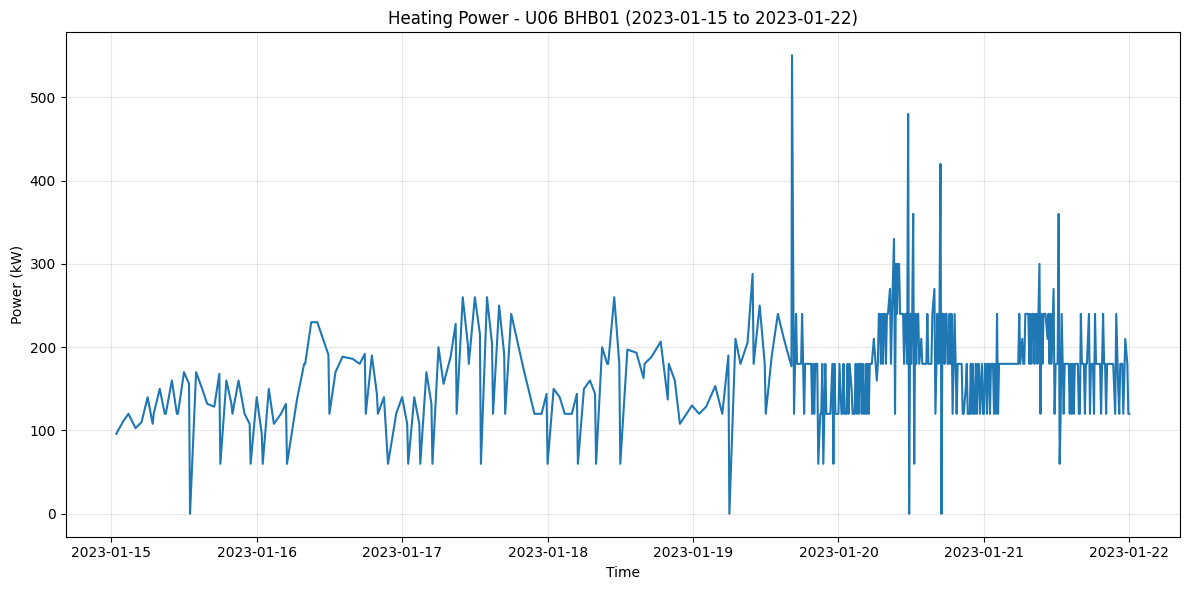

In [76]:
# TODO: Move this toa function in a dedicated file

# Quick data snippet - load and display a small sample
building_code = "U06"
year = "2023"
measurement_point = "BHB01"

# Date range for plotting\
start_date = pd.to_datetime("2023-01-15")
end_date = pd.to_datetime("2023-01-22")

# Load energy data
sample_file = CAMPUS_DATA_DIR / building_code / year / f"{building_code}_{measurement_point}_näit_{year}.csv"
sample_df = pd.read_csv(sample_file)
sample_df['Time'] = pd.to_datetime(sample_df['Time'], format='%Y/%m/%d %H:%M:%S')

# Filter for date range and plot
plot_df = sample_df[(sample_df['Time'] >= start_date) & (sample_df['Time'] <= end_date)].copy()

# Convert cumulative energy to power (kW) for the plot
plot_df = plot_df.sort_values('Time').reset_index(drop=True)
plot_df['time_diff_hours'] = plot_df['Time'].diff().dt.total_seconds() / 3600
plot_df['energy_diff_mwh'] = plot_df['Value'].diff()
plot_df['power_kw'] = (plot_df['energy_diff_mwh'] / plot_df['time_diff_hours']) * 1000

# Create plot - Power only
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Plot Power (kW) - derived from energy differences
ax.plot(plot_df['Time'], plot_df['power_kw'])
ax.set_ylabel('Power (kW)')
ax.set_xlabel('Time')
ax.set_title(f'Heating Power - {building_code} {measurement_point} ({start_date.date()} to {end_date.date()})')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [77]:
# In this block, we'll build a full dataframe for a given building.
building_code = "U06"
years = ["2022", "2023", "2024"]

# Get all measurement points for the building
measurement_points = building_overview_data[building_overview_data["Hoone"] == building_code]["ID convert"].unique()
measurement_point_details = ["näit", "pealevoolu temp", "tagasivoolu temp"]

# Clean the measurement points to remove "building_code."
measurement_points = [point.replace(f"{building_code}.", "") for point in measurement_points]
print(f"Measurement points: {measurement_points}")

# Build a dictionary: column_name -> list of dataframes (from different years)
column_data = {}

total_files = len(years) * len(measurement_points) * len(measurement_point_details)
print(f"Checking up to {total_files} files...")

file_count = 0
for year in years:
    for measurement_point in measurement_points:
        for measurement_point_detail in measurement_point_details:
            file_path = f"{CAMPUS_DATA_DIR}/{building_code}/{year}/{building_code}_{measurement_point}_{measurement_point_detail}_{year}.csv"
            
            # Check if file exists (some combinations might not have data)
            if not os.path.exists(file_path):
                continue
            
            file_count += 1
            
            # Column name WITHOUT year - data from all years goes into same column
            col_name = f"{measurement_point}_{measurement_point_detail}"
            
            print(f"[{file_count}] Loading: {col_name} ({year})", end=" ... ")
            
            # Read the file
            df = pd.read_csv(file_path)
            
            # Keep only Time and Value
            df = df[["Time", "Value"]].copy()
            df["Time"] = pd.to_datetime(df["Time"])
            df = df.rename(columns={"Value": col_name})
            
            # Add to column_data dict
            if col_name not in column_data:
                column_data[col_name] = []
            column_data[col_name].append(df)
            
            print(f"OK ({len(df)} rows)")

print(f"\nSuccessfully loaded {file_count} files into {len(column_data)} columns")

# For each column, stack all years vertically, then deduplicate by Time
print("\nCombining years for each column...")
column_series = {}

for col_name, dfs in column_data.items():
    # Stack all years vertically
    combined = pd.concat(dfs, ignore_index=True)
    
    # Group by Time and take mean (handles duplicates)
    series = combined.groupby("Time")[col_name].mean()
    column_series[col_name] = series
    print(f"  {col_name}: {len(series)} unique timestamps")

# Combine all columns into one dataframe
print("\nBuilding final dataframe...")
dataframe = pd.DataFrame(column_series)
dataframe = dataframe.sort_index().reset_index()

print(f"\nDone! Final dataframe: {dataframe.shape[0]} rows, {dataframe.shape[1]} columns")
print(f"Columns: {list(dataframe.columns)}")

Measurement points: ['BHB01', 'BHB02', 'BHB03', 'BHB04', 'BHB05', 'BHB06']
Checking up to 54 files...
[1] Loading: BHB01_näit (2022) ... OK (13520 rows)
[2] Loading: BHB01_pealevoolu temp (2022) ... OK (8785 rows)
[3] Loading: BHB01_tagasivoolu temp (2022) ... OK (8839 rows)
[4] Loading: BHB02_näit (2022) ... OK (11134 rows)
[5] Loading: BHB02_pealevoolu temp (2022) ... OK (8818 rows)
[6] Loading: BHB02_tagasivoolu temp (2022) ... OK (8874 rows)
[7] Loading: BHB03_näit (2022) ... OK (11134 rows)
[8] Loading: BHB03_pealevoolu temp (2022) ... OK (8888 rows)
[9] Loading: BHB03_tagasivoolu temp (2022) ... OK (8866 rows)
[10] Loading: BHB04_näit (2022) ... OK (11134 rows)
[11] Loading: BHB04_pealevoolu temp (2022) ... OK (8887 rows)
[12] Loading: BHB04_tagasivoolu temp (2022) ... OK (8887 rows)
[13] Loading: BHB05_näit (2022) ... OK (5297 rows)
[14] Loading: BHB05_pealevoolu temp (2022) ... OK (8894 rows)
[15] Loading: BHB05_tagasivoolu temp (2022) ... OK (8854 rows)
[16] Loading: BHB06_näi

In [78]:
# Resample to hourly resolution (aggregate sub-hourly measurements)
print(f"Before resampling: {dataframe.shape[0]} rows")

# Set Time as index for resampling
df_resampled = dataframe.set_index("Time")

# Resample to hourly, taking mean of all values within each hour
# This handles timestamps like 00:20, 00:30 -> averaged into 00:00
df_resampled = df_resampled.resample("1h").mean()

# Reset index to make Time a column again
df_resampled = df_resampled.reset_index()

print(f"After resampling: {df_resampled.shape[0]} rows")
print(f"Expected for 3 years at 1h resolution: ~{3 * 365 * 24} rows")

# Check time range
print(f"\nTime range: {df_resampled['Time'].min()} to {df_resampled['Time'].max()}")

# Replace the original dataframe
dataframe = df_resampled
dataframe.head(10)

Before resampling: 37670 rows
After resampling: 26275 rows
Expected for 3 years at 1h resolution: ~26280 rows

Time range: 2022-01-01 00:00:00 to 2024-12-30 18:00:00


,Time,BHB01_näit,BHB01_pealevoolu temp,BHB01_tagasivoolu temp,BHB02_näit,BHB02_pealevoolu temp,BHB02_tagasivoolu temp,BHB03_näit,BHB03_pealevoolu temp,BHB03_tagasivoolu temp,BHB04_näit,BHB04_pealevoolu temp,BHB04_tagasivoolu temp,BHB05_näit,BHB05_pealevoolu temp,BHB05_tagasivoolu temp,BHB06_näit,BHB06_pealevoolu temp,BHB06_tagasivoolu temp
0,2022-01-01 00:00:00,11305.785000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-01-01 01:00:00,11306.010000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-01-01 02:00:00,11306.180000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-01-01 03:00:00,11306.420000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-01-01 04:00:00,11306.623333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2022-01-01 05:00:00,11306.790000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2022-01-01 06:00:00,11306.983333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2022-01-01 07:00:00,11307.140000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2022-01-01 08:00:00,11307.343333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2022-01-01 09:00:00,11307.575000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [79]:
# Create NEW hourly consumption columns in kWh from cumulative "näit" readings
# Original näit columns (MWh cumulative) are kept, new _kWh columns are added

nait_cols = [col for col in dataframe.columns if "näit" in col]

print(f"Creating {len(nait_cols)} new hourly consumption columns (kWh):")
for col in nait_cols:
    # New column name: replace "näit" with "kWh"
    new_col = col.replace("näit", "näit_delta")
    
    # Calculate hourly diff and convert MWh -> MWh
    dataframe[new_col] = dataframe[col].diff()
kwh_cols = [col for col in dataframe.columns if "kWh" in col]
print(f"\nNew kWh columns: {kwh_cols}")
print(f"Note: First row will have NaN (no previous value to diff from)")

# Show sample with new columns
dataframe.head(10)

Creating 6 new hourly consumption columns (kWh):

New kWh columns: []
Note: First row will have NaN (no previous value to diff from)


,Time,BHB01_näit,BHB01_pealevoolu temp,BHB01_tagasivoolu temp,BHB02_näit,BHB02_pealevoolu temp,BHB02_tagasivoolu temp,BHB03_näit,BHB03_pealevoolu temp,BHB03_tagasivoolu temp,...,BHB05_tagasivoolu temp,BHB06_näit,BHB06_pealevoolu temp,BHB06_tagasivoolu temp,BHB01_näit_delta,BHB02_näit_delta,BHB03_näit_delta,BHB04_näit_delta,BHB05_näit_delta,BHB06_näit_delta
0,2022-01-01 00:00:00,11305.785000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-01-01 01:00:00,11306.010000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.225000,NaN,NaN,NaN,NaN,NaN
2,2022-01-01 02:00:00,11306.180000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.170000,NaN,NaN,NaN,NaN,NaN
3,2022-01-01 03:00:00,11306.420000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.240000,NaN,NaN,NaN,NaN,NaN
4,2022-01-01 04:00:00,11306.623333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.203333,NaN,NaN,NaN,NaN,NaN
5,2022-01-01 05:00:00,11306.790000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.166667,NaN,NaN,NaN,NaN,NaN
6,2022-01-01 06:00:00,11306.983333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.193333,NaN,NaN,NaN,NaN,NaN
7,2022-01-01 07:00:00,11307.140000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.156667,NaN,NaN,NaN,NaN,NaN
8,2022-01-01 08:00:00,11307.343333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.203333,NaN,NaN,NaN,NaN,NaN
9,2022-01-01 09:00:00,11307.575000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.231667,NaN,NaN,NaN,NaN,NaN


In [ ]:
u06_dataframe = dataframe

u06_dataframe.head(5)

,Time,BHB01_näit,BHB01_pealevoolu temp,BHB01_tagasivoolu temp,BHB02_näit,BHB02_pealevoolu temp,BHB02_tagasivoolu temp,BHB03_näit,BHB03_pealevoolu temp,BHB03_tagasivoolu temp,...,BHB05_tagasivoolu temp,BHB06_näit,BHB06_pealevoolu temp,BHB06_tagasivoolu temp,BHB01_näit_delta,BHB02_näit_delta,BHB03_näit_delta,BHB04_näit_delta,BHB05_näit_delta,BHB06_näit_delta
0,2022-01-01 00:00:00,11305.785000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-01-01 01:00:00,11306.010000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.225000,NaN,NaN,NaN,NaN,NaN
2,2022-01-01 02:00:00,11306.180000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.170000,NaN,NaN,NaN,NaN,NaN
3,2022-01-01 03:00:00,11306.420000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.240000,NaN,NaN,NaN,NaN,NaN
4,2022-01-01 04:00:00,11306.623333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.203333,NaN,NaN,NaN,NaN,NaN


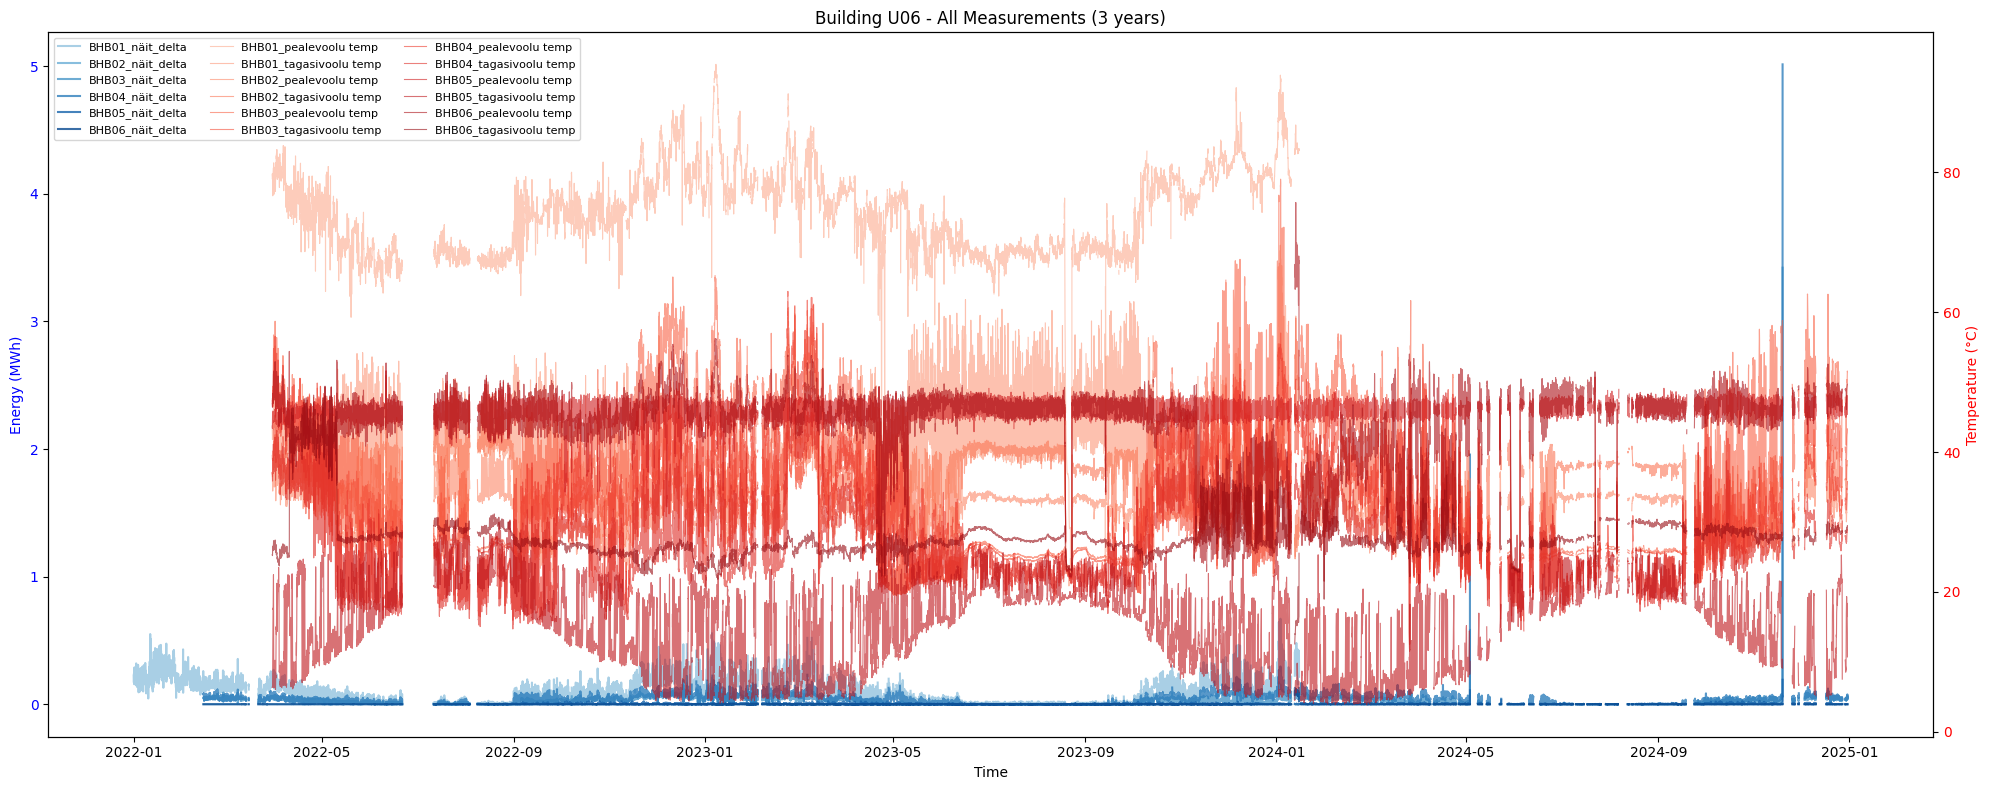

MWh columns (6): ['BHB01_näit_delta', 'BHB02_näit_delta', 'BHB03_näit_delta', 'BHB04_näit_delta', 'BHB05_näit_delta', 'BHB06_näit_delta']
Temp columns (12): ['BHB01_pealevoolu temp', 'BHB01_tagasivoolu temp', 'BHB02_pealevoolu temp', 'BHB02_tagasivoolu temp', 'BHB03_pealevoolu temp', 'BHB03_tagasivoolu temp', 'BHB04_pealevoolu temp', 'BHB04_tagasivoolu temp', 'BHB05_pealevoolu temp', 'BHB05_tagasivoolu temp', 'BHB06_pealevoolu temp', 'BHB06_tagasivoolu temp']


In [ ]:
# Let's draw these out - dual axis plot for MWh and °C

fig, ax1 = plt.subplots(figsize=(20, 8))

# Separate columns by unit type
mwh_cols = [col for col in dataframe.columns if "näit_delta" in col]
temp_cols = [col for col in dataframe.columns if "temp" in col]

# Plot MWh on left axis (6 lines)
colors_mwh = plt.cm.Blues(np.linspace(0.4, 0.9, len(mwh_cols)))
for col, color in zip(mwh_cols, colors_mwh):
    ax1.plot(dataframe["Time"], dataframe[col], label=col, color=color, alpha=0.8)

ax1.set_xlabel("Time")
ax1.set_ylabel("Energy (MWh)", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# Plot °C on right axis (12 lines)
ax2 = ax1.twinx()
colors_temp = plt.cm.Reds(np.linspace(0.3, 0.9, len(temp_cols)))
for col, color in zip(temp_cols, colors_temp):
    ax2.plot(dataframe["Time"], dataframe[col], label=col, color=color, alpha=0.6, linewidth=0.8)

ax2.set_ylabel("Temperature (°C)", color="red")
ax2.tick_params(axis="y", labelcolor="red")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8, ncol=3)

plt.title(f"Building {building_code} - All Measurements (3 years)")
plt.tight_layout()
plt.show()

print(f"MWh columns ({len(mwh_cols)}): {mwh_cols}")
print(f"Temp columns ({len(temp_cols)}): {temp_cols}")



In [ ]:
# Little things remain with the data clearning. We now have hourly measurements.
# TODO: How much data is missing? Where do we have every column present?
# TODO: The "näit" column is cumulative, we need to convert it to power (kW/h) first.
# Is takign average of the values correct? Should it maybe be lower one or the first one?



In [ ]:
# Let's attempt to also read the keskkonnaportaal file

weather_data = pd.read_csv(WEATHER_DATA_FILE, delimiter=";")

# Distinct elements in the "element_nimi_eng - Element name (eng)" column
distinct_features = weather_data["element_nimi_eng - Element name (eng)"].unique()
print(f"Distinct features ({len(distinct_features)}): {distinct_features}")

Distinct features (10): ['Air pressure at sea level' 'Precipitation (hourly sum)'
 'Relative humidity' 'Sunshine duration (hourly sum)'
 'Air temperature (hourly max)' 'Air temperature (hourly min)'
 'Air temperature' 'Wind direction (10 min avg)' 'Wind speed (10 min avg)'
 'Wind gust (hourly max)']


In [ ]:
# Now let's make it a dataframe, where each distinct feature is a column instead.

# First, create a datetime column from year, month, day, hour
weather_data["Time"] = pd.to_datetime(
    weather_data["aasta - Year of measurement, UTC time"].astype(str) + "-" +
    weather_data["kuu - Month of measurement, UTC time"].astype(str).str.zfill(2) + "-" +
    weather_data["paev - Day of measurement, UTC time"].astype(str).str.zfill(2) + " " +
    weather_data["tund - Hour of measurement, UTC time"].astype(str).str.zfill(2) + ":00:00"
)

# The values use comma as decimal separator (European format), convert to float
weather_data["value"] = weather_data["vaartus - The measured value"].astype(str).str.replace(",", ".").astype(float)

# Create shorter feature names from the element codes and names
weather_data["feature"] = weather_data["element_kood - Element code, local"]

# Pivot the dataframe: datetime as index, features as columns
weather_df = weather_data.pivot_table(
    index="Time",
    columns="feature",
    values="value",
    aggfunc="mean"  # In case of duplicates, take the mean
).reset_index()

# Rename columns to be more descriptive using the element names
feature_mapping = weather_data[["element_kood - Element code, local", "element_nimi_eng - Element name (eng)"]].drop_duplicates()
feature_mapping = dict(zip(feature_mapping["element_kood - Element code, local"], feature_mapping["element_nimi_eng - Element name (eng)"]))

# Apply the mapping to rename columns (except datetime)
weather_df.columns = ["Time"] + [feature_mapping.get(col, col) for col in weather_df.columns[1:]]

print(f"Weather DataFrame shape: {weather_df.shape}")
print(f"Date range: {weather_df['Time'].min()} to {weather_df['Time'].max()}")
print(f"\nColumns: {list(weather_df.columns)}")
print(f"\nFirst few rows:")
weather_df.head()

Weather DataFrame shape: (34704, 11)
Date range: 2022-01-01 00:00:00 to 2025-12-16 23:00:00

Columns: ['Time', 'Air pressure at sea level', 'Precipitation (hourly sum)', 'Relative humidity', 'Sunshine duration (hourly sum)', 'Air temperature', 'Air temperature (hourly min)', 'Air temperature (hourly max)', 'Wind direction (10 min avg)', 'Wind speed (10 min avg)', 'Wind gust (hourly max)']

First few rows:


,Time,Air pressure at sea level,Precipitation (hourly sum),Relative humidity,Sunshine duration (hourly sum),Air temperature,Air temperature (hourly min),Air temperature (hourly max),Wind direction (10 min avg),Wind speed (10 min avg),Wind gust (hourly max)
0,2022-01-01 00:00:00,1001.6,0.3,99.0,0.0,0.0,-0.8,0.0,85.0,1.4,2.0
1,2022-01-01 01:00:00,1002.0,0.4,100.0,0.0,-0.1,-0.1,0.1,45.0,1.0,2.5
2,2022-01-01 02:00:00,1002.4,0.5,100.0,0.0,-0.1,-0.2,-0.1,32.0,1.5,2.7
3,2022-01-01 03:00:00,1003.0,0.3,100.0,0.0,-0.3,-0.3,-0.1,29.0,1.9,3.3
4,2022-01-01 04:00:00,1004.1,0.2,99.0,0.0,-0.4,-0.4,-0.2,17.0,1.3,3.2


In [ ]:
# Now combining and renaming the two dataframes

combined_df = pd.merge(u06_dataframe, weather_df, on="Time", how="left")
combined_df.head(5)

combined_df.info()

combined_df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26275 entries, 0 to 26274
Data columns (total 35 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Time                            26275 non-null  datetime64[ns]
 1   BHB01_näit                      16154 non-null  float64       
 2   BHB01_pealevoolu temp           14326 non-null  float64       
 3   BHB01_tagasivoolu temp          14325 non-null  float64       
 4   BHB02_näit                      21412 non-null  float64       
 5   BHB02_pealevoolu temp           20643 non-null  float64       
 6   BHB02_tagasivoolu temp          20643 non-null  float64       
 7   BHB03_näit                      21412 non-null  float64       
 8   BHB03_pealevoolu temp           20644 non-null  float64       
 9   BHB03_tagasivoolu temp          20644 non-null  float64       
 10  BHB04_näit                      21412 non-null  float64       
 11  BH

,Time,BHB01_näit,BHB01_pealevoolu temp,BHB01_tagasivoolu temp,BHB02_näit,BHB02_pealevoolu temp,BHB02_tagasivoolu temp,BHB03_näit,BHB03_pealevoolu temp,BHB03_tagasivoolu temp,...,Air pressure at sea level,Precipitation (hourly sum),Relative humidity,Sunshine duration (hourly sum),Air temperature,Air temperature (hourly min),Air temperature (hourly max),Wind direction (10 min avg),Wind speed (10 min avg),Wind gust (hourly max)
count,26275,16154.000000,14326.000000,14325.000000,21412.000000,20643.000000,20643.000000,21412.000000,20644.000000,20644.000000,...,26275.000000,26270.000000,26245.000000,26275.000000,26275.000000,26275.000000,26275.000000,26234.000000,26234.000000,26232.000000
mean,2023-07-02 09:00:00,12290.345407,74.061141,41.207751,0.572667,31.169599,35.107430,449.542074,36.293384,31.475488,...,1012.428301,0.072037,79.558240,14.118249,7.399071,6.964655,7.865945,185.782458,2.988355,6.029376
min,2022-01-01 00:00:00,11305.785000,22.330000,20.860000,0.185000,20.710000,21.815000,143.391000,19.510000,19.460000,...,960.900000,0.000000,13.000000,0.000000,-19.800000,-20.100000,-18.800000,1.000000,0.100000,0.600000
25%,2022-10-01 16:30:00,11854.202500,69.045000,37.630000,0.375000,28.520000,31.830000,275.774250,26.075000,25.650000,...,1005.400000,0.000000,69.000000,0.000000,0.500000,0.300000,0.800000,133.000000,1.800000,3.800000
50%,2023-07-02 09:00:00,12315.310000,74.330000,40.860000,0.635000,31.365000,34.960000,475.546000,35.920000,31.260000,...,1013.600000,0.000000,85.000000,0.000000,6.800000,6.400000,7.200000,198.000000,2.800000,5.700000
75%,2024-04-01 01:30:00,12747.587500,78.300000,44.090000,0.733000,33.480000,38.365000,608.794000,44.530000,36.576250,...,1020.600000,0.000000,93.000000,24.000000,14.600000,14.000000,15.200000,247.000000,3.900000,7.900000
max,2024-12-30 18:00:00,13180.620000,95.420000,69.570000,0.878000,49.715000,50.950000,723.347000,79.005000,57.020000,...,1048.300000,24.900000,100.000000,60.000000,32.000000,31.200000,32.900000,360.000000,10.500000,20.400000
std,NaN,495.707948,6.661087,5.493449,0.191958,3.581891,4.402533,161.755347,10.417804,6.409708,...,12.020637,0.431531,17.035067,23.397672,8.825141,8.689513,8.989737,87.410738,1.540645,2.982783


In [ ]:
# Reorder and rename columns
# Each BHB group has 4 features: measurement, supply temp, return temp, delta

column_mapping = {
    # Time
    "Time"                                    : "datetime",
    
    # BHB01 - (fill in building/system name)
    "BHB01_näit"                              : "bhb01_measurement_cumulative_mwh",
    "BHB01_pealevoolu temp"                   : "bhb01_supply_flow_temp_c",
    "BHB01_tagasivoolu temp"                  : "bhb01_return_flow_temp_c",
    "BHB01_näit_delta"                        : "bhb01_measurement_delta_mwh",
    
    # BHB02 - (fill in building/system name)
    "BHB02_näit"                              : "bhb02_measurement_cumulative_mwh",
    "BHB02_pealevoolu temp"                   : "bhb02_supply_flow_temp_c",
    "BHB02_tagasivoolu temp"                  : "bhb02_return_flow_temp_c",
    "BHB02_näit_delta"                        : "bhb02_measurement_delta_mwh",
    
    # BHB03 - (fill in building/system name)
    "BHB03_näit"                              : "bhb03_measurement_cumulative_mwh",
    "BHB03_pealevoolu temp"                   : "bhb03_supply_flow_temp_c",
    "BHB03_tagasivoolu temp"                  : "bhb03_return_flow_temp_c",
    "BHB03_näit_delta"                        : "bhb03_measurement_delta_mwh",
    
    # BHB04 - (fill in building/system name)
    "BHB04_näit"                              : "bhb04_measurement_cumulative_mwh",
    "BHB04_pealevoolu temp"                   : "bhb04_supply_flow_temp_c",
    "BHB04_tagasivoolu temp"                  : "bhb04_return_flow_temp_c",
    "BHB04_näit_delta"                        : "bhb04_measurement_delta_mwh",
    
    # BHB05 - (fill in building/system name)
    "BHB05_näit"                              : "bhb05_measurement_cumulative_mwh",
    "BHB05_pealevoolu temp"                   : "bhb05_supply_flow_temp_c",
    "BHB05_tagasivoolu temp"                  : "bhb05_return_flow_temp_c",
    "BHB05_näit_delta"                        : "bhb05_measurement_delta_mwh",
    
    # BHB06 - (fill in building/system name)
    "BHB06_näit"                              : "bhb06_measurement_cumulative_mwh",
    "BHB06_pealevoolu temp"                   : "bhb06_supply_flow_temp_c",
    "BHB06_tagasivoolu temp"                  : "bhb06_return_flow_temp_c",
    "BHB06_näit_delta"                        : "bhb06_measurement_delta_mwh",
    
    # Weather data
    "Air pressure at sea level"               : "air_pressure_hpa",
    "Precipitation (hourly sum)"              : "precipitation_mm",
    "Relative humidity"                       : "relative_humidity_pct",
    "Sunshine duration (hourly sum)"          : "sunshine_duration_min",
    "Air temperature"                         : "air_temp_c",
    "Air temperature (hourly min)"            : "air_temp_min_c",
    "Air temperature (hourly max)"            : "air_temp_max_c",
    "Wind direction (10 min avg)"             : "wind_direction_deg",
    "Wind speed (10 min avg)"                 : "wind_speed_ms",
    "Wind gust (hourly max)"                  : "wind_gust_max_ms",
}

# Adds a constant indoor temp
combined_df["indoor_temp_constant_c"] = 21
# Define the desired column order (grouped by BHB, then weather)
column_order = [
    "datetime",

    "indoor_temp_constant_c",
    
    # BHB01
    "bhb01_measurement_cumulative_mwh",
    "bhb01_supply_flow_temp_c",
    "bhb01_return_flow_temp_c",
    "bhb01_measurement_delta_mwh",
    
    # BHB02
    "bhb02_measurement_cumulative_mwh",
    "bhb02_supply_flow_temp_c",
    "bhb02_return_flow_temp_c",
    "bhb02_measurement_delta_mwh",
    
    # BHB03
    "bhb03_measurement_cumulative_mwh",
    "bhb03_supply_flow_temp_c",
    "bhb03_return_flow_temp_c",
    "bhb03_measurement_delta_mwh",
    
    # BHB04
    "bhb04_measurement_cumulative_mwh",
    "bhb04_supply_flow_temp_c",
    "bhb04_return_flow_temp_c",
    "bhb04_measurement_delta_mwh",
    
    # BHB05
    "bhb05_measurement_cumulative_mwh",
    "bhb05_supply_flow_temp_c",
    "bhb05_return_flow_temp_c",
    "bhb05_measurement_delta_mwh",
    
    # BHB06
    "bhb06_measurement_cumulative_mwh",
    "bhb06_supply_flow_temp_c",
    "bhb06_return_flow_temp_c",
    "bhb06_measurement_delta_mwh",
    
    # Weather
    "air_pressure_hpa",
    "precipitation_mm",
    "relative_humidity_pct",
    "sunshine_duration_min",
    "air_temp_c",
    "air_temp_min_c",
    "air_temp_max_c",
    "wind_direction_deg",
    "wind_speed_ms",
    "wind_gust_max_ms",
]

# Apply renaming and reordering
combined_df = combined_df.rename(columns=column_mapping)
combined_df = combined_df[column_order]

print(f"Renamed and reordered DataFrame:")
print(f"Shape: {combined_df.shape}")
print(f"\nColumns:\n{list(combined_df.columns)}")
combined_df.head()

Renamed and reordered DataFrame:
Shape: (26275, 36)

Columns:
['datetime', 'indoor_temp_constant_c', 'bhb01_measurement_cumulative_mwh', 'bhb01_supply_flow_temp_c', 'bhb01_return_flow_temp_c', 'bhb01_measurement_delta_mwh', 'bhb02_measurement_cumulative_mwh', 'bhb02_supply_flow_temp_c', 'bhb02_return_flow_temp_c', 'bhb02_measurement_delta_mwh', 'bhb03_measurement_cumulative_mwh', 'bhb03_supply_flow_temp_c', 'bhb03_return_flow_temp_c', 'bhb03_measurement_delta_mwh', 'bhb04_measurement_cumulative_mwh', 'bhb04_supply_flow_temp_c', 'bhb04_return_flow_temp_c', 'bhb04_measurement_delta_mwh', 'bhb05_measurement_cumulative_mwh', 'bhb05_supply_flow_temp_c', 'bhb05_return_flow_temp_c', 'bhb05_measurement_delta_mwh', 'bhb06_measurement_cumulative_mwh', 'bhb06_supply_flow_temp_c', 'bhb06_return_flow_temp_c', 'bhb06_measurement_delta_mwh', 'air_pressure_hpa', 'precipitation_mm', 'relative_humidity_pct', 'sunshine_duration_min', 'air_temp_c', 'air_temp_min_c', 'air_temp_max_c', 'wind_direction_deg',

,datetime,indoor_temp_constant_c,bhb01_measurement_cumulative_mwh,bhb01_supply_flow_temp_c,bhb01_return_flow_temp_c,bhb01_measurement_delta_mwh,bhb02_measurement_cumulative_mwh,bhb02_supply_flow_temp_c,bhb02_return_flow_temp_c,bhb02_measurement_delta_mwh,...,air_pressure_hpa,precipitation_mm,relative_humidity_pct,sunshine_duration_min,air_temp_c,air_temp_min_c,air_temp_max_c,wind_direction_deg,wind_speed_ms,wind_gust_max_ms
0,2022-01-01 00:00:00,21,11305.785000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1001.6,0.3,99.0,0.0,0.0,-0.8,0.0,85.0,1.4,2.0
1,2022-01-01 01:00:00,21,11306.010000,NaN,NaN,0.225000,NaN,NaN,NaN,NaN,...,1002.0,0.4,100.0,0.0,-0.1,-0.1,0.1,45.0,1.0,2.5
2,2022-01-01 02:00:00,21,11306.180000,NaN,NaN,0.170000,NaN,NaN,NaN,NaN,...,1002.4,0.5,100.0,0.0,-0.1,-0.2,-0.1,32.0,1.5,2.7
3,2022-01-01 03:00:00,21,11306.420000,NaN,NaN,0.240000,NaN,NaN,NaN,NaN,...,1003.0,0.3,100.0,0.0,-0.3,-0.3,-0.1,29.0,1.9,3.3
4,2022-01-01 04:00:00,21,11306.623333,NaN,NaN,0.203333,NaN,NaN,NaN,NaN,...,1004.1,0.2,99.0,0.0,-0.4,-0.4,-0.2,17.0,1.3,3.2
